# PC. 14 - Perceptrons) Utilizando a implementação de MLP fornecida pelo professor da disciplina, ou então uma implementação do Pytorch ou, ainda, do TensorFlow, proceda com a identificação usando RNA para o seguinte sistema dinâmico:

<img src="./img/yk.png" width="30%">

Sendo u(k) dado conforme a Figura 21.

<img src="./img/plot_yk.png" width="30%">

Figura 21: Sinal de entrada para o sistema não linear.

## Definição da MLP:

In [2]:
# Basic models used to build a multilayer perceptron that
# uses a backpropagation algorithm to learn from data.
#
# Author: Prof. Fabrício Galende Marques de Carvalho
#
import numpy as np

class Neuron:
    """ 
    Basic neuron model used to build a single
    processing unit.
    """
    def __init__(self, act_func, d_act_func, pre_act=0, post_act=0):
        self.activation_function = act_func
        self.activation_function_derivative = d_act_func
        self.pre_activation = pre_act
        self.post_activation = post_act

    def process(self,v):
        self.pre_activation = v
        self.post_activation = self.activation_function(v)
        return self.post_activation

    def process_d(self):
        return self.activation_function_derivative(self.pre_activation)


class Layer:
    """
    Model for a single processing Layer.
    Once a layer is created, an additional input is always created
    to include bias.
    """
    def __init__( self, dimension, neuron_model, act_func, d_act_func ):
        """
        dimension: number of neurons in the layer
        No initial condition is passed to neurons. To change it, each
        neuron must be accessed through self.neurons array.
        """
        self.dimension = dimension
        self.neuron_model = neuron_model
        self.neurons = np.empty(dimension, dtype=object)
        self.pre_activation = np.zeros((dimension,1))
        self.post_activation = np.zeros((dimension,1))
        self.local_derivatives = np.zeros((dimension,1))
        for neuron_index in range(dimension):
            self.neurons[neuron_index] = neuron_model(act_func, d_act_func)   

    def process(self, v, learn=False):
        """
        v is the vector (dimension x1), which corresponds
        to the local field for each neuron
        """
        self.pre_activation = np.array(v).reshape(-1,1) ## reshape(-1,1) -> any number of lines and only one column
        output = []
        deriv = []
        for i,neuron in enumerate(self.neurons):
            output.append(neuron.process(v[i]))
            if learn:
                deriv.append(neuron.process_d())
        self.post_activation = np.array(output).reshape(-1,1)
        if learn:
            self.local_derivatives = np.array(deriv).reshape(-1,1)
        return np.array(output).reshape(-1,1)

    def process_d(self):
        output = []
        for neuron in self.neurons:
            output.append(neuron.process_d()[0])
        self.local_derivatives = np.array(output).reshape(-1,1)
        return self.local_derivatives

class FFNeuralNetwork:
    """
      A class that models a feedforward neural network
    """
    def __init__(self, topology, layers, W0 = None, zero_init = False, rand_seed = 0):
        """
         topology: array that contains the number of neurons
         per layer, including input layer (i.e., a network
         with topology [3,2,1] contains three inputs, 2 
         neurons in the hidden layer and one output layer.
        """
        self.topology = topology        # defines a dense feedforward NN
        self.n_layers = len(topology)-1 # number of processing layers
        self.layers = layers
        self.weights = W0
        if self.weights is None: # no initialization was provided
            self.weights = []
            if not zero_init: #random initialization is performed
                np.random.seed(rand_seed)
                for i in range(len(topology)-1):
                    #negative and positive initial weights: 
                    self.weights.append(np.random.uniform(low=-1.0, high=1.0, size=(self.topology[i+1], self.topology[i] + 1))) 
                    # only positive initial weights:
                    # self.weights.append(np.random.rand(self.topology[i+1],self.topology[i]+1)) ## bias is taken into account here
            else:
                for i in range(len(topology)-1):
                    self.weights.append(np.zeros((self.topology[i+1],self.topology[i]+1))) ## bias is taken into account here

    def process(self, x, learn=False):
        """
        Performs the forward propagation and gets neural network output from
        vector input x
        """
        for i, layer in enumerate(self.layers):
            if i == 0:
                x_in = np.vstack( (x,[[1]] )) # here we stack the bias input for the first layer 
            else:
                x_in = np.vstack( [self.layers[i-1].post_activation, [[1]]]) 
            v = self.weights[i] @ x_in
            layer.process(v, learn)
        return self.layers[self.n_layers-1].post_activation

    def backprop(self, x, y_d, eta):
        """
        Here we implement the backpropagation algorithm.
        It is assumed that x and y_d are both column vectors and 
        it is also assumed that the layers were appropriately
        initialized.

        This algorithm is implemented for a single example learning 
        and it can be easily wrapped in a version that is applicable
        to some training set.

        eta: learning rate
        """

        # First we propagate through the network
        output = self.process(x, learn=True)
        # Then we compute the output error vector
        error_vector = y_d - output

        # Now we compute the gradients for the output and hidden layers, in
        # reverse order
        grad_indices = list(range(self.n_layers))
        grad_indices.reverse()
        local_grads = []
        for i in range(self.n_layers):
            local_grads.append(np.zeros((self.topology[i+1],1)))
        for l_idx in grad_indices:
            if l_idx == (self.n_layers - 1) : #output layer
                 #local gradient for the output layer
                 delta_k = error_vector * self.layers[self.n_layers-1].local_derivatives  #element-wise operation
                 local_grads[l_idx] = delta_k
            else:                 
                # delta_k_1 = phi'(v_k_1) *  (W_k^T. delta_k ) 
                delta_k_1 =  self.layers[l_idx].local_derivatives * (self.weights[(l_idx + 1)][:, :-1].T @ local_grads[(l_idx+1)] )
                local_grads[l_idx] = delta_k_1
        # now we can compute the appropriate weight corrections:
        for i in range(self.n_layers):
            if i == 0: #input layer
                self.weights[i] = self.weights[i] + eta * local_grads[i] @ np.vstack((x,[[1]])).T
            else:
                self.weights[i] = self.weights[i] + eta * local_grads[i] @ np.vstack( (self.layers[i-1].post_activation, [[1]])).T
        #Return the error just to measure the training process effectiveness:
        return error_vector

### Definição da Arquitetura:

- O sistema que queremos identificar é não linear, dependente do tempo, com memória de ordem 2, ou seja o sistema precisa olhar dois instantes passados para calcular o valor atual y(k - 1) e y(k - 2). A Memória de ordem 2 significa que o sistema usa os dois últimos valores do passado para determinar o presente.

A arquitetura da rede pensada para esse sistema:

- 3 entradas, pois temos y(k-1), y(k-2) e u(k);
- 8 neurônios ocultos, método heurístico;
- E uma camada de saída;

Usar a função tangente hiperbólica para capturar a não-linearidade do sistema e usar linear na saída pois é melhor para a regreção para permitir números reais. A tangente hiperbólica cria padrões não lineares já a linear combina esses padrões livremente.

#### Definição da função tangente hiperbólica:

![image.png](./img/tanh_formula.png)

![image.png](./img/tanh.png)

In [52]:
def tanh(x):
    return np.tanh(x)

def d_tanh(x):
    return 1 - np.tanh(x)**2

#### Definição da função linear

In [53]:
def linear(x):
    return x

def d_linear(x):
    return 1

#### Definição da MLP

In [55]:
input_size = 3

seed = 42

topology = [input_size, 8, 1]

layers = [
    Layer(8, Neuron, tanh, d_tanh),
    Layer(1, Neuron, linear, d_linear)
]

nn = FFNeuralNetwork(topology, layers, rand_seed = seed)

## Simulação do sistema

Para cada instante k, usar os instantes anteriores "y(k-1) e y(k-2)", calcular o sistema não linear e somar a entrada u(k).

- u(k) = +1 saída sobe;
- u(k) = -1 saída desce;

In [56]:
def generate_u(k):
    return 1 if (k // 50) % 2 == 0 else -1

N = 400

y = np.zeros(N)
u = np.zeros(N)

for k in range(N):
    u[k] = generate_u(k)

for k in range(2, N):
    y[k] = (y[k-1] * y[k-2]) / (0.01 + abs(y[k-1]) + abs(y[k-2])) + u[k]

## Criação do Dataset:

A criação do dataset consiste em transformar a dinâmica temporal do sistema em pares de entrada e saída para a MLP.

Para cada instante k (a partir de k = 2), usamos como entrada o vetor "y(k-1), y(k-2) e u(k)", que contém a "memória" do sistema e a dinâmica atual.

Assim, ao percorrer a série simulada, gera-se uma matriz X com essas entradas e um vetor Y com as saídas correspondentes, convertendo o problema dinâmico em um problema supervisionado de regressão que a rede consegue aprender.

In [57]:
X = []
Y = []

for k in range(2, N):
    X.append([y[k-1], y[k-2], u[k]])
    Y.append([y[k]])
    
X = np.array(X)
Y = np.array(Y)

## Normalização:

In [58]:
X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
Y = (Y - Y.mean(axis=0)) / (Y.std(axis=0) + 1e-8)

## Treinamento:

Epoch 0, Erro: 0.10426846993425307
Epoch 100, Erro: 0.008421902413814986
Epoch 200, Erro: 0.0061078876412362796
Epoch 300, Erro: 0.00456298241092663
Epoch 400, Erro: 0.0029753855510015192


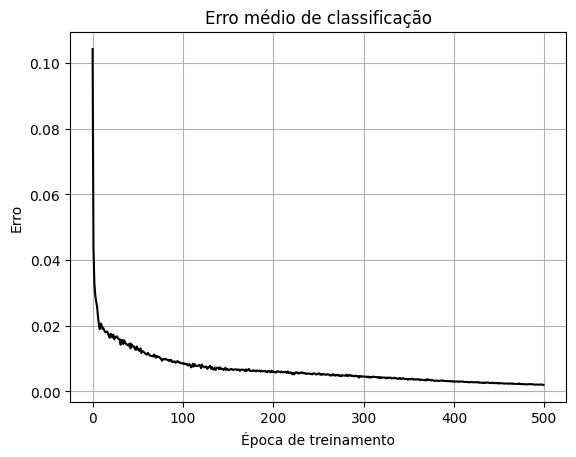

In [59]:
learning_rate = 0.045
n_epochs = 500

e_epoch = []
indices = list(range(len(X)))

for epoch in range(n_epochs):
    e_point = []
    np.random.shuffle(indices)
    
    for k in indices:
        x = X[k].reshape(-1,1)
        y_true = Y[k].reshape(-1,1)
        
        error = nn.backprop(x, y_true, learning_rate)
        err_val = error[0][0]
        e_point.append(err_val)
    
    e_epoch.append(np.mean(np.abs(e_point)))
    
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Erro: {e_epoch[-1]}")

plt.plot(e_epoch, color="black")
plt.title("Erro médio de classificação")
plt.xlabel("Época de treinamento")
plt.ylabel("Erro")
plt.grid()
plt.show()

## Avaliação:

Essa rede agora será usada para prever a saída do sistema ao longo do tempo.

Iniciar com valores iniciais de y e, a cada instante k, alimentamos a rede com "y(k−1),y(k−2),u(k)".

Criando um dataset para a previsão do y.

### Simulação com a nossa rede:

In [48]:
y_pred = np.zeros(N)

for k in range(2, N):
    x_input = np.array([y_pred[k-1], y_pred[k-2], u[k]])
    
    # normalizar com MESMA estatística
    x_input = (x_input - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
    
    y_hat = nn.process(x_input.reshape(-1,1))[0][0]
    
    # desnormalizar
    y_hat = y_hat * Y.std() + Y.mean()
    
    y_pred[k] = y_hat

Em uma simulação livre foram usadas as próprias saídas previstas pela rede como entrada para os próximos passos, gerando uma sequência _y_pred_.

Agora é só comparar com a saída real do sistema. Isso permite verificar se a rede não apenas ajusta pontos isolados, mas também reproduz corretamente a dinâmica ao longo do tempo, observando erros acumulados e a fidelidade do comportamento geral.

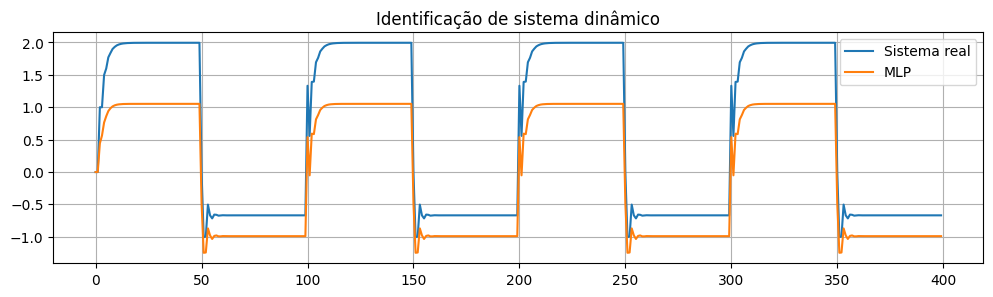

In [51]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (12, 3))
plt.plot(y, label="Sistema real")
plt.plot(y_pred, label="MLP")
plt.legend()
plt.title("Identificação de sistema dinâmico")
plt.grid()
plt.show()

A rede aprendeu a dinâmica do sistema, mas não acertou a magnitude.

Pode ser por inconsistências na normalização e desnormalização dos dados também podem distorcer a escala.

Assim, mesmo aprendendo bem o formato da dinâmica, a rede fica “travada” em uma faixa de valores menor e não consegue reproduzir corretamente a amplitude do sinal.